## Load Libraries

In [ ]:
# Import the libraries
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

from collections import Counter
from pathlib import Path

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import lightgbm as lgb
from sklearn.inspection    import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics        import make_scorer


## Mount Working Drive

In [ ]:
# Connect the Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import sys
import os

# Adjust the path to include the parent directory of 'src'
# Assuming 'src' is located at /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/src
project_root = '/content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.cost_matrix import CostMatrix, ThresholdOptimiser, COST_MATRIX_RAW, N_CLASSES, CLASS_DESCRIPTIONS

## Set Data Paths

In [ ]:
data_path = Path('/content/drive/MyDrive/MasterThesis-2026/Dataset/data/')
field_description_path = data_path/'data_description.docx'

# Training data ----
# Set the path for train operational readout data
data_path_train_operational_readouts = data_path/'train_operational_readouts.csv'

# Set the path for train specification data
data_path_train_specifications = data_path/'train_specifications.csv'

# Set the path for train service record data
data_path_train_tte = data_path/'train_tte.csv'

# validation Data ----
# Set the path for validation operational readout data
data_path_validation_operational_readouts = data_path/'validation_operational_readouts.csv'

# Set the path for validation specifications
data_path_validation_specifications = data_path/'validation_specifications.csv'

# Set the path for validation labels data
data_path_validation_labels = data_path/'validation_labels.csv'

# Test Data ----
# Set the path for test operational readout data
data_path_test_operational_readouts = data_path/'test_operational_readouts.csv'

# Set the path for test specifications
data_path_test_specifications = data_path/'test_specifications.csv'

# Set the path for test labels data
data_path_test_labels = data_path/'test_labels.csv'


# Data analysis

## Exploratory data **analysis**

### Training Data - Load Training Data

In [ ]:
# Read train operational readout data
train_operational_readout_data = pd.read_csv(data_path_train_operational_readouts)

In [ ]:
# Read train specification data
train_specification_data = pd.read_csv(data_path_train_specifications)

In [ ]:
# Read train tte data
train_tte_data = pd.read_csv(data_path_train_tte)

### Training Data - Preprocessing

#### Analyse `train_operational_readout_data` Data

In [ ]:
print("Shape of train_operational_readout_data:", train_operational_readout_data.shape)
print("\nInformation about train_operational_readout_data:")
train_operational_readout_data.info()
print("\nFirst 5 rows of train_operational_readout_data:")
display(train_operational_readout_data[train_operational_readout_data['vehicle_id']== 11153])

Shape of train_operational_readout_data: (1122452, 107)

Information about train_operational_readout_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122452 entries, 0 to 1122451
Columns: 107 entries, vehicle_id to 397_35
dtypes: float64(106), int64(1)
memory usage: 916.3 MB

First 5 rows of train_operational_readout_data:


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
427056,11153,2.4,77130.0,392.0,2815891.0,8.0,0.0,433755.0,585480.0,352051.0,...,45497.0,1748.0,424.0,24.0,732.0,28104.0,49444.0,7122.0,1428.0,32.0
427057,11153,8.4,294420.0,1415.0,10704827.0,8.0,5910.0,859215.0,2322465.0,1268206.0,...,222906.0,8520.0,1485.0,48.0,1920.0,139160.0,242445.0,32871.0,5097.0,180.0
427058,11153,9.4,314430.0,1464.0,11425393.0,8.0,5910.0,903660.0,2410725.0,1338691.0,...,239314.0,9484.0,1574.0,52.0,2028.0,147936.0,261837.0,35599.0,5730.0,180.0
427059,11153,16.2,513105.0,4985.0,18554625.0,8.0,5910.0,1228125.0,3521685.0,1919626.0,...,401258.0,15256.0,2574.0,64.0,3004.0,249756.0,428785.0,56663.0,9394.0,217.0
427060,11153,18.8,621345.0,6203.0,22322730.0,8.0,5910.0,1358565.0,3974896.0,2183041.0,...,478308.0,17661.0,3039.0,64.0,3392.0,295424.0,513858.0,68312.0,10751.0,241.0
427061,11153,19.2,639210.0,6498.0,22973622.0,8.0,5910.0,1365660.0,4015891.0,2212427.0,...,491293.0,18441.0,3147.0,64.0,3509.0,303596.0,529602.0,70777.0,10987.0,242.0
427062,11153,24.8,850050.0,12504.0,30473522.0,16.0,5910.0,1689915.0,4857257.0,2796213.0,...,638278.0,24297.0,4152.0,72.0,4450.0,387985.0,688987.0,95609.0,15680.0,286.0
427063,11153,27.2,958275.0,15262.0,34313050.0,16.0,5911.0,1796715.0,5296232.0,3081603.0,...,707858.0,27154.0,4724.0,72.0,4835.0,425605.0,765647.0,106798.0,18124.0,310.0
427064,11153,28.0,997680.0,16844.0,35736549.0,16.0,5911.0,1819920.0,5456192.0,3189873.0,...,733374.0,28314.0,5049.0,72.0,4983.0,442389.0,797276.0,112302.0,19149.0,322.0
427065,11153,29.0,1037655.0,17537.0,37106335.0,16.0,5911.0,1848435.0,5623562.0,3257493.0,...,760210.0,29326.0,5198.0,76.0,5043.0,454649.0,822644.0,115423.0,19465.0,322.0


#### Analyse `train_specification_data` Data

In [ ]:
print("Shape of train_specification_data:", train_specification_data.shape)
print("\nInformation about train_specification_data:")
train_specification_data.info()
print("\nFirst 5 rows of train_specification_data:")
display(train_specification_data.head())

Shape of train_specification_data: (23550, 9)

Information about train_specification_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23550 entries, 0 to 23549
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   vehicle_id  23550 non-null  int64 
 1   Spec_0      23550 non-null  object
 2   Spec_1      23550 non-null  object
 3   Spec_2      23550 non-null  object
 4   Spec_3      23550 non-null  object
 5   Spec_4      23550 non-null  object
 6   Spec_5      23550 non-null  object
 7   Spec_6      23550 non-null  object
 8   Spec_7      23550 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.6+ MB

First 5 rows of train_specification_data:


,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1


#### Analyse `train_service_records_data` Data

In [ ]:
print("Shape of train_service_records_data:", train_tte_data.shape)
print("\nInformation about train_service_records_data:")
train_tte_data.info()
print("\nFirst 5 rows of train_service_records_data:")
display(train_tte_data.head())

Shape of train_service_records_data: (23550, 3)

Information about train_service_records_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23550 entries, 0 to 23549
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   vehicle_id                 23550 non-null  int64  
 1   length_of_study_time_step  23550 non-null  float64
 2   in_study_repair            23550 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 552.1 KB

First 5 rows of train_service_records_data:


,vehicle_id,length_of_study_time_step,in_study_repair
0,0,510.0,0
1,2,281.8,0
2,3,293.4,0
3,4,210.0,0
4,5,360.4,0


#### Feature Aggregation - train_operational_data

##### Step 1: Identify Features for Aggregation

First, we need to decide which columns to aggregate and what type of aggregation to perform. For `train_operational_readout_data`, most features are numerical. We will group by `vehicle_id` and calculate descriptive statistics for all other numerical columns.

In [ ]:
# Identify numerical columns (excluding 'vehicle_id' as it's the grouping key)
numerical_cols = train_operational_readout_data.select_dtypes(include=np.number).columns.drop('vehicle_id', errors='ignore').tolist()

print("Numerical columns to be aggregated:")
print(numerical_cols[:5], "... (total", len(numerical_cols), ")")


Numerical columns to be aggregated:
['time_step', '171_0', '666_0', '427_0', '837_0'] ... (total 106 )


##### Step 2: Define Aggregation Functions

We will use `mean`, `std` (standard deviation), `min`, `max`, `count`, and `median` for the numerical features. This will give a good overview of the central tendency, spread, and range of each feature for every vehicle.

In [ ]:
aggregation_functions = {col: ['mean', 'std', 'min', 'max', 'count', 'median'] for col in numerical_cols}


##### Step 3: Group by `vehicle_id` and Aggregate

Now, we'll apply the `groupby()` method on `vehicle_id` and then use the `agg()` method with our defined aggregation functions. The resulting DataFrame will have each `vehicle_id` as an index and multi-level columns representing the feature and its aggregated statistic.

In [ ]:
summary_operational_readout = train_operational_readout_data.groupby('vehicle_id').agg(aggregation_functions)

print("Shape of the summarized data:", summary_operational_readout.shape)
print("\nFirst 5 rows of the summarized operational readout data by vehicle_id:")
display(summary_operational_readout.head())

Shape of the summarized data: (23550, 636)

First 5 rows of the summarized operational readout data by vehicle_id:


time_step                                               171_0  \
                  mean         std   min    max count median          mean   
vehicle_id                                                                   
0           258.130233  148.787213  11.2  507.4   172  274.3  5.310002e+06   
2           167.939394   80.951474   1.4  281.0    33  177.6  3.374853e+06   
3           131.608451   91.691168   0.2  291.2    71  136.6  3.274506e+06   
4            99.588235   51.335829   3.8  203.0    17   96.4  1.815351e+06   
5           164.690909  106.699661   0.0  357.6    44  192.0  2.570454e+06   

                                                ...   397_34                  \
                     std       min         max  ...      min       max count   
vehicle_id                                      ...                            
0           2.958805e+06  167985.0  10189950.0  ...  17874.0  138939.0   172   
2           1.607343e+06   65520.0   5648790.0  ...   1081.0   57511.0    33   
3           2.474695e+06    1530.0   7603590.0  ...    296.0   76915.0    71   
4           1.481630e+06  210915.0   4842780.0  ...  44692.0  453350.0    17   
5           1.897820e+06   29175.0   6623040.0  ...     32.0  515597.0    44   

                           397_35                                            
              median         mean          std    min     max count  median  
vehicle_id                                                                   
0            74021.0   640.848837    97.543275  452.0   792.0   172   655.0  
2            49345.0   674.484848   199.667555   88.0   793.0    33   714.0  
3            32474.0   443.070423   194.469559  165.0   712.0    71   436.0  
4           190194.0  1184.176471   361.842375  712.0  1962.0    17   961.0  
5           426409.5  5666.227273  3119.675653    0.0  8663.0    44  7896.0  

[5 rows x 636 columns]

##### Step 4: Flatten Column Names (Optional but Recommended)

The aggregation creates multi-level column names (e.g., `('171_0', 'mean')`). To make them easier to work with, we can flatten them into a single string format (e.g., `'171_0_mean'`).

In [ ]:
summary_operational_readout.columns = ['_'.join(col).strip() for col in summary_operational_readout.columns.values]

print("First 5 rows of the summarized operational readout data with flattened column names:")
display(summary_operational_readout.head())

summary_operational_readout.shape

First 5 rows of the summarized operational readout data with flattened column names:


,time_step_mean,time_step_std,time_step_min,time_step_max,time_step_count,time_step_median,171_0_mean,171_0_std,171_0_min,171_0_max,...,397_34_min,397_34_max,397_34_count,397_34_median,397_35_mean,397_35_std,397_35_min,397_35_max,397_35_count,397_35_median
vehicle_id,,,,,,,,,,,,,,,,,,,,,
0,258.130233,148.787213,11.2,507.4,172,274.3,5.310002e+06,2.958805e+06,167985.0,10189950.0,...,17874.0,138939.0,172,74021.0,640.848837,97.543275,452.0,792.0,172,655.0
2,167.939394,80.951474,1.4,281.0,33,177.6,3.374853e+06,1.607343e+06,65520.0,5648790.0,...,1081.0,57511.0,33,49345.0,674.484848,199.667555,88.0,793.0,33,714.0
3,131.608451,91.691168,0.2,291.2,71,136.6,3.274506e+06,2.474695e+06,1530.0,7603590.0,...,296.0,76915.0,71,32474.0,443.070423,194.469559,165.0,712.0,71,436.0
4,99.588235,51.335829,3.8,203.0,17,96.4,1.815351e+06,1.481630e+06,210915.0,4842780.0,...,44692.0,453350.0,17,190194.0,1184.176471,361.842375,712.0,1962.0,17,961.0
5,164.690909,106.699661,0.0,357.6,44,192.0,2.570454e+06,1.897820e+06,29175.0,6623040.0,...,32.0,515597.0,44,426409.5,5666.227273,3119.675653,0.0,8663.0,44,7896.0


(23550, 636)

#### Feature Extraction for train_operational_data

Feature extraction (and selection) is the process of creating new features from existing ones and selecting the most relevant features to improve model performance, reduce training time, and enhance interpretability. For your `summary_operational_readout` table, which has already been aggregated by `vehicle_id`, here's how we can proceed:


##### Step 1: Initial Data Health Check on summary_operational_readout
Before diving into complex feature engineering, it's crucial to understand the characteristics of your already aggregated features.

a. Missing Values: Check for any NaN values that might have appeared due to the aggregation process (e.g., standard deviation of a single data point is NaN) or were propagated from the original data. High percentages of missing values in a feature might lead to its removal or require careful imputation.

b. Constant Features: Identify and remove features that have a constant value across all vehicle_ids. These features provide no predictive power and only add noise and computational overhead.

c. Highly Correlated Features: Examine features that are highly correlated with each other. Redundant information can slow down training, make models less interpretable, and sometimes lead to multicollinearity issues. You might choose to keep only one from a highly correlated pair or use dimensionality reduction techniques.

Step 1a: Handling Missing Values in `summary_operational_readout`

In [ ]:
# Calculate the percentage of missing values for each column
missing_percentage = summary_operational_readout.isnull().sum() / len(summary_operational_readout) * 100

# Display columns with missing values and their percentages, sorted descending
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
print("Percentage of Missing Values per Feature in summary_operational_readout (Top 20):")
display(missing_percentage.head(20))

# Identify columns to drop if they have more than a certain threshold of missing values
# For example, let's set a threshold of 70%
missing_threshold = 70
columns_to_drop = missing_percentage[missing_percentage > missing_threshold].index.tolist()

if columns_to_drop:
    print(f"\nColumns to drop (more than {missing_threshold}% missing values): {len(columns_to_drop)} columns")
    print(columns_to_drop)
    summary_operational_readout_cleaned = summary_operational_readout.drop(columns=columns_to_drop)
else:
    print(f"\nNo columns with more than {missing_threshold}% missing values to drop.")
    summary_operational_readout_cleaned = summary_operational_readout.copy()


Percentage of Missing Values per Feature in summary_operational_readout (Top 20):


,0
167_0_std,0.012739
167_1_std,0.012739
167_3_std,0.012739
167_2_std,0.012739
167_4_std,0.012739
167_6_std,0.012739
167_8_std,0.012739
167_7_std,0.012739
167_5_std,0.012739
167_9_std,0.012739



No columns with more than 70% missing values to drop.


In [ ]:
# Impute remaining missing values using the median
print("\nMissing values before imputation:")
print(summary_operational_readout_cleaned.isnull().sum().sum())

# Median is often preferred over mean for skewed distributions and robustness to outliers
for col in summary_operational_readout_cleaned.columns:
    if summary_operational_readout_cleaned[col].isnull().any():
        median_val = summary_operational_readout_cleaned[col].median()
        summary_operational_readout_cleaned[col].fillna(median_val, inplace=True)

print("\nMissing values after imputation:")
print(summary_operational_readout_cleaned.isnull().sum().sum()) # Should be 0

print("\nFirst 5 rows of the cleaned summary operational readout data:")
display(summary_operational_readout_cleaned.head())


Missing values before imputation:
131


/tmp/ipykernel_1846/2476326121.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  summary_operational_readout_cleaned[col].fillna(median_val, inplace=True)



Missing values after imputation:
0

First 5 rows of the cleaned summary operational readout data:


,time_step_mean,time_step_std,time_step_min,time_step_max,time_step_count,time_step_median,171_0_mean,171_0_std,171_0_min,171_0_max,...,397_34_min,397_34_max,397_34_count,397_34_median,397_35_mean,397_35_std,397_35_min,397_35_max,397_35_count,397_35_median
vehicle_id,,,,,,,,,,,,,,,,,,,,,
0,258.130233,148.787213,11.2,507.4,172,274.3,5.310002e+06,2.958805e+06,167985.0,10189950.0,...,17874.0,138939.0,172,74021.0,640.848837,97.543275,452.0,792.0,172,655.0
2,167.939394,80.951474,1.4,281.0,33,177.6,3.374853e+06,1.607343e+06,65520.0,5648790.0,...,1081.0,57511.0,33,49345.0,674.484848,199.667555,88.0,793.0,33,714.0
3,131.608451,91.691168,0.2,291.2,71,136.6,3.274506e+06,2.474695e+06,1530.0,7603590.0,...,296.0,76915.0,71,32474.0,443.070423,194.469559,165.0,712.0,71,436.0
4,99.588235,51.335829,3.8,203.0,17,96.4,1.815351e+06,1.481630e+06,210915.0,4842780.0,...,44692.0,453350.0,17,190194.0,1184.176471,361.842375,712.0,1962.0,17,961.0
5,164.690909,106.699661,0.0,357.6,44,192.0,2.570454e+06,1.897820e+06,29175.0,6623040.0,...,32.0,515597.0,44,426409.5,5666.227273,3119.675653,0.0,8663.0,44,7896.0


Step 1b: Handling Constant Values in `summary_operational_readout`

In [ ]:
# Identify constant columns (columns with only one unique value)
constant_columns = [col for col in summary_operational_readout_cleaned.columns if summary_operational_readout_cleaned[col].nunique() == 1]

if constant_columns:
    print("\nIdentified Constant Features (to be considered for removal):")
    for col in constant_columns:
        print(f"- {col}: Unique value = {summary_operational_readout_cleaned[col].iloc[0]}")

    # Optionally, you can drop these columns if desired. For now, we just list them.
    # summary_operational_readout_cleaned = summary_operational_readout_cleaned.drop(columns=constant_columns)
    # print(f"\n{len(constant_columns)} constant columns removed. New shape: {summary_operational_readout_cleaned.shape}")
else:
    print("\nNo constant features identified in summary_operational_readout_cleaned.")



No constant features identified in summary_operational_readout_cleaned.


Step 1c: Handling Highly co-related features in `summary_operational_readout_cleaned`

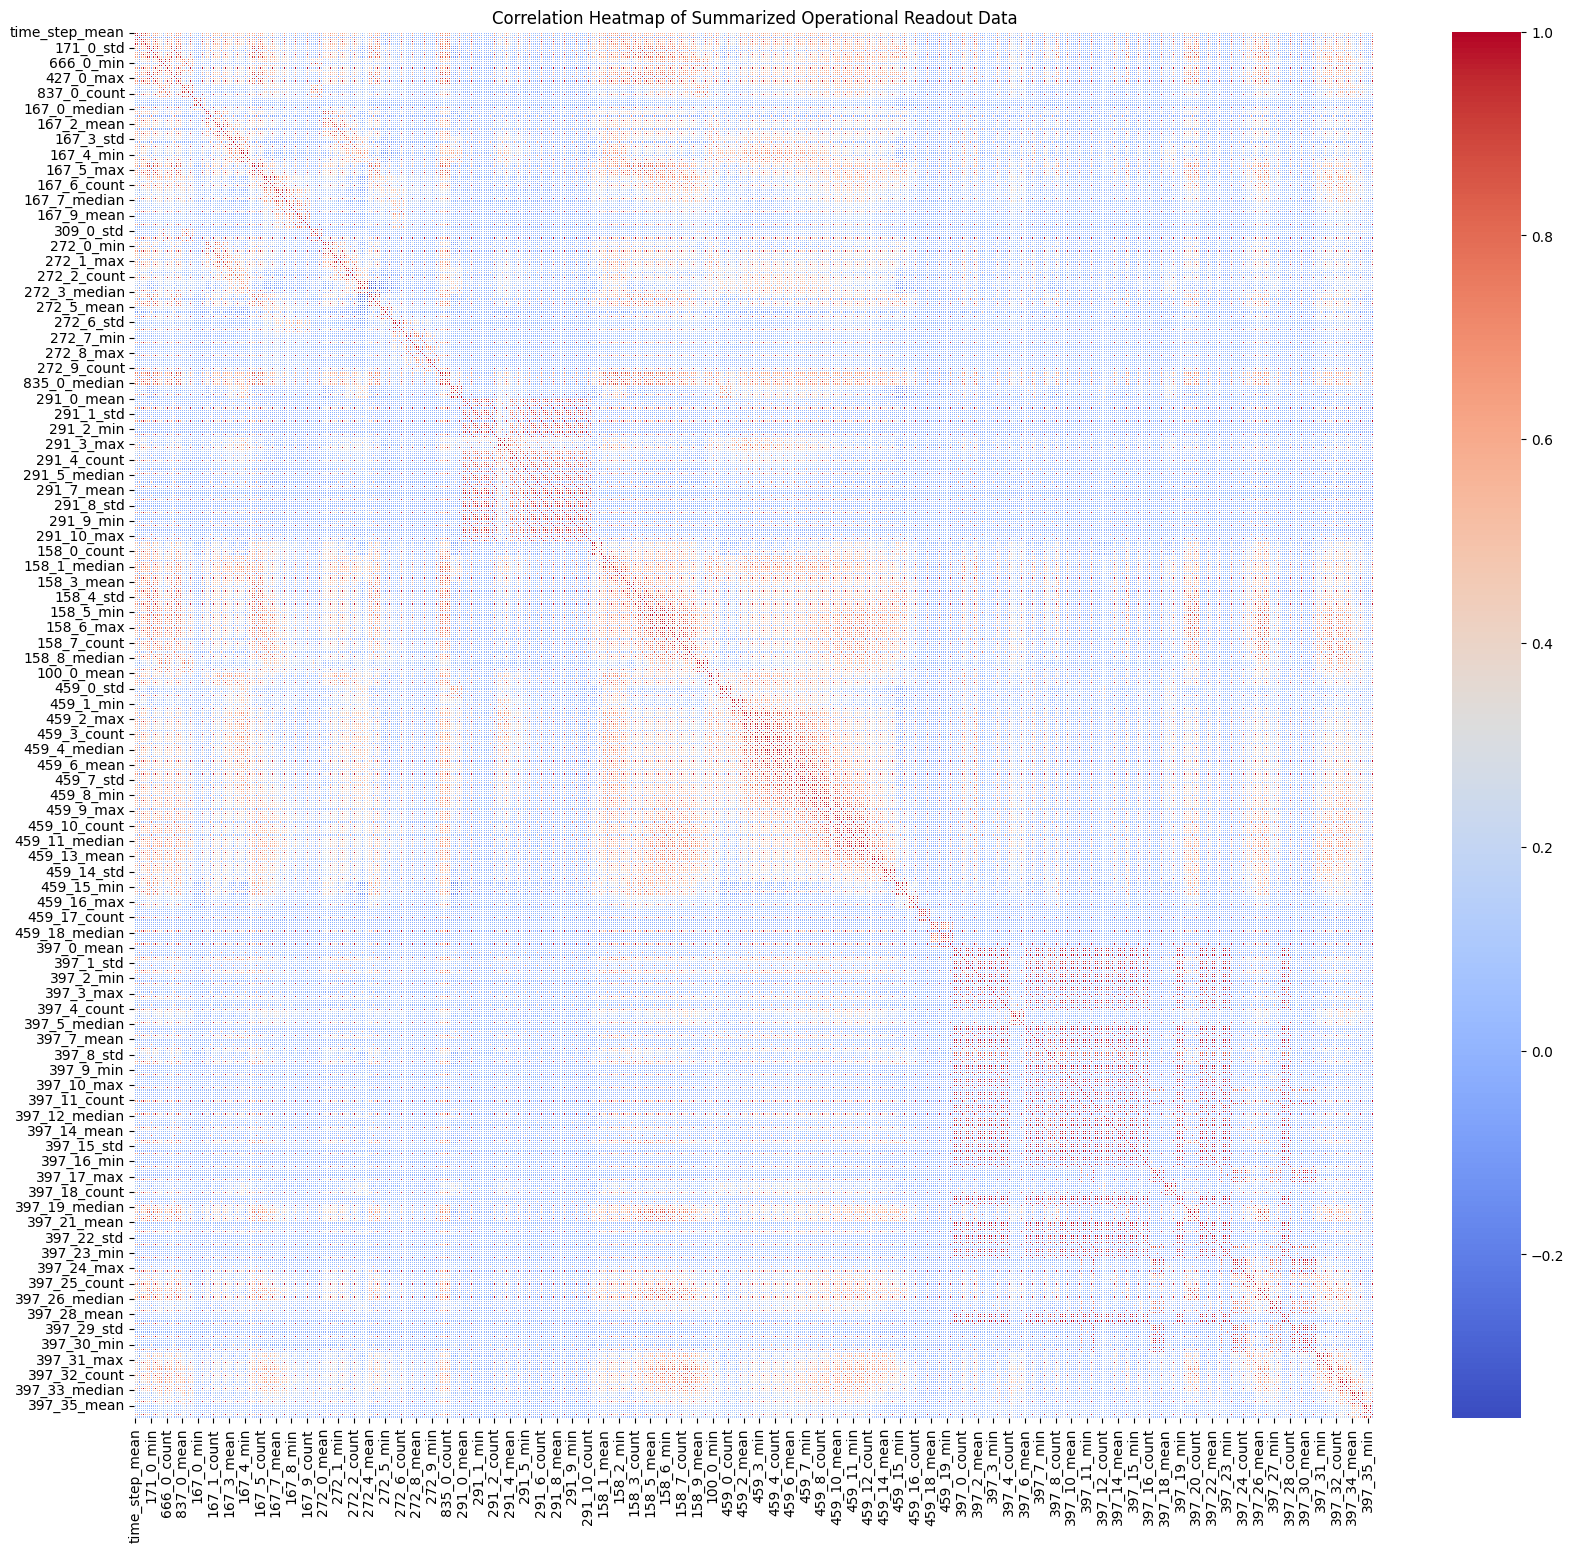


Identified Highly Correlated Feature Pairs (absolute correlation > 0.9):
- time_step_count and 171_0_count: Correlation = 1.00
- 167_0_count and 167_1_count: Correlation = 1.00
- 167_0_count and 167_2_count: Correlation = 1.00
- 167_0_count and 167_3_count: Correlation = 1.00
- 167_0_count and 167_4_count: Correlation = 1.00
- 167_0_count and 167_5_count: Correlation = 1.00
- 167_0_count and 167_6_count: Correlation = 1.00
- 167_0_count and 167_7_count: Correlation = 1.00
- 167_0_count and 167_8_count: Correlation = 1.00
- 167_0_count and 167_9_count: Correlation = 1.00
- 167_1_count and 167_2_count: Correlation = 1.00
- 167_1_count and 167_3_count: Correlation = 1.00
- 167_1_count and 167_4_count: Correlation = 1.00
- 167_1_count and 167_5_count: Correlation = 1.00
- 167_1_count and 167_6_count: Correlation = 1.00
- 167_1_count and 167_7_count: Correlation = 1.00
- 167_1_count and 167_8_count: Correlation = 1.00
- 167_1_count and 167_9_count: Correlation = 1.00
- 167_2_count and 167_

,time_step_mean,time_step_min,time_step_count,171_0_mean,171_0_min,666_0_mean,666_0_min,837_0_mean,837_0_std,167_0_mean,...,397_31_mean,397_31_min,397_32_mean,397_32_min,397_33_mean,397_33_min,397_34_mean,397_34_min,397_35_mean,397_35_min
vehicle_id,,,,,,,,,,,,,,,,,,,,,
0,258.130233,11.2,172,5.310002e+06,167985.0,197902.168605,10787.0,27056.273256,11661.207037,4110.500000,...,1.944636e+06,150228.0,2.273773e+06,261904.0,560261.418605,93172.0,74468.220930,17874.0,640.848837,452.0
2,167.939394,1.4,33,3.374853e+06,65520.0,192030.212121,2226.0,40504.787879,17694.700827,6965.454545,...,7.284255e+05,12089.0,1.042075e+06,10388.0,222924.727273,2413.0,44156.727273,1081.0,674.484848,88.0
3,131.608451,0.2,71,3.274506e+06,1530.0,102097.492958,28.0,45315.323944,33663.198228,3144.872340,...,3.343648e+05,4.0,1.146652e+06,221.0,228721.971831,40.0,31454.070423,296.0,443.070423,165.0
4,99.588235,3.8,17,1.815351e+06,210915.0,85981.352941,21371.0,58584.882353,45935.892427,6838.500000,...,2.253964e+05,143769.0,8.256451e+05,388012.0,545739.764706,134709.0,201874.647059,44692.0,1184.176471,712.0
5,164.690909,0.0,44,2.570454e+06,29175.0,131730.204545,259.0,71448.227273,49499.535615,29149.600000,...,2.789735e+05,396.0,9.546550e+05,276.0,480050.818182,28.0,308762.159091,32.0,5666.227273,0.0


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = summary_operational_readout_cleaned.corr()

# Plotting the heatmap to visualize correlations
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Summarized Operational Readout Data')
plt.show()

# Identify highly correlated pairs (e.g., absolute correlation > 0.9)
high_corr_threshold = 0.9
highly_correlated_pairs = []

# Get unique pairs by iterating over the upper triangle of the correlation matrix
for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > high_corr_threshold:
            highly_correlated_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

# Sort pairs by absolute correlation value in descending order
highly_correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

columns_to_drop_from_corr = set()

# Iterate through the highly correlated pairs and decide which one to drop
# A simple strategy is to drop the second feature in the pair, as long as neither is already marked for dropping

if highly_correlated_pairs:
    print(f"\nIdentified Highly Correlated Feature Pairs (absolute correlation > {high_corr_threshold}):")
    for f1, f2, corr_val in highly_correlated_pairs:
        print(f"- {f1} and {f2}: Correlation = {corr_val:.2f}")

        if f1 not in columns_to_drop_from_corr and f2 not in columns_to_drop_from_corr:
          columns_to_drop_from_corr.add(f2) # Mark the second feature for dropping

    print("\nConsider removing one feature from each highly correlated pair to reduce redundancy and improve model performance.")

    if columns_to_drop_from_corr:
        print(f"Dropping {len(columns_to_drop_from_corr)} highly correlated features:")
        print(list(columns_to_drop_from_corr))
        summary_operational_readout_cleaned_final = summary_operational_readout_cleaned.drop(columns=list(columns_to_drop_from_corr))
        print(f"New shape of the DataFrame: {summary_operational_readout_cleaned_final.shape}")
    else:
        print("No highly correlated features to drop based on the threshold.")
        summary_operational_readout_cleaned_final = summary_operational_readout_cleaned.copy()

    print("\nFirst 5 rows of the DataFrame after dropping highly correlated features:")
    display(summary_operational_readout_cleaned_final.head())
else:
    print(f"\nNo highly correlated feature pairs found with an absolute correlation greater than {high_corr_threshold}.")

##### Step 2: Incorporating the Target Variable (Failure Prediction Context)
For failure prediction, the summary_operational_readout table, on its own, is not enough. You need to connect these operational summaries to the actual failure events. This involves merging your summary_operational_readout with the train_tte (Time To Event/Failure) data using vehicle_id as the key. This merged dataset will allow you to link aggregated operational features to the time until failure or a binary failure indicator.

In [ ]:
merged_data = pd.merge(summary_operational_readout_cleaned_final, train_tte_data, on='vehicle_id', how='left')
merged_data = pd.merge(merged_data, train_specification_data, on='vehicle_id', how='left')

print("Shape of the final merged data:", merged_data.shape)
print("\nFirst 5 rows of the final merged data:")
display(merged_data.head())

print("\nInformation about the final merged data:")
merged_data.info()

# Quick check for missing values in the newly merged columns
print("\nMissing values in the merged data (top 20):")
display(merged_data.isnull().sum()[merged_data.isnull().sum() > 0].sort_values(ascending=False).head(20))

Shape of the final merged data: (23550, 166)

First 5 rows of the final merged data:


,vehicle_id,time_step_mean,time_step_min,time_step_count,171_0_mean,171_0_min,666_0_mean,666_0_min,837_0_mean,837_0_std,...,length_of_study_time_step,in_study_repair,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,0,258.130233,11.2,172,5.310002e+06,167985.0,197902.168605,10787.0,27056.273256,11661.207037,...,510.0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat0
1,2,167.939394,1.4,33,3.374853e+06,65520.0,192030.212121,2226.0,40504.787879,17694.700827,...,281.8,0,Cat0,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0,Cat1
2,3,131.608451,0.2,71,3.274506e+06,1530.0,102097.492958,28.0,45315.323944,33663.198228,...,293.4,0,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,4,99.588235,3.8,17,1.815351e+06,210915.0,85981.352941,21371.0,58584.882353,45935.892427,...,210.0,0,Cat0,Cat0,Cat2,Cat1,Cat0,Cat0,Cat0,Cat1
4,5,164.690909,0.0,44,2.570454e+06,29175.0,131730.204545,259.0,71448.227273,49499.535615,...,360.4,0,Cat0,Cat2,Cat2,Cat0,Cat0,Cat0,Cat0,Cat1



Information about the final merged data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23550 entries, 0 to 23549
Columns: 166 entries, vehicle_id to Spec_7
dtypes: float64(155), int64(3), object(8)
memory usage: 29.8+ MB

Missing values in the merged data (top 20):


,0


##### Step 3: Feature Selection Based on Predictive Power (Post-Merge)
Once you have a dataset where each vehicle_id has its summarized operational features and its corresponding target variable (e.g., time_to_event or a failure_flag), you can apply more advanced feature selection techniques:

###### a. Statistical Methods: For numerical features, you can use statistical tests (e.g., ANOVA F-value) to measure the relationship between each feature and the target variable. For categorical features (if any), Chi-squared tests can be used.

Analyse the numerical features relationship between each feature and the target variable using ANOVA F-value test

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.preprocessing import LabelEncoder

# Prepare features (X) and target (y) again, ensuring consistency with previous steps
X_statistical = merged_data.drop(columns=['vehicle_id', 'length_of_study_time_step', 'in_study_repair'])
y_statistical = merged_data['in_study_repair']

# Identify categorical columns for one-hot encoding
categorical_cols_statistical = X_statistical.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical features to create X_encoded_statistical
X_encoded_statistical = pd.get_dummies(X_statistical, columns=categorical_cols_statistical, drop_first=True)

print("Shape of features for statistical selection after encoding:", X_encoded_statistical.shape)

# Apply SelectKBest with f_classif (ANOVA F-value)
# We'll select all features initially to get their scores, then sort.
f_selector = SelectKBest(f_classif, k='all')
f_selector.fit(X_encoded_statistical, y_statistical)

# Get the scores and P-values
f_scores = pd.DataFrame({'feature': X_encoded_statistical.columns, 'f_score': f_selector.scores_, 'p_value': f_selector.pvalues_})

# Sort features by F-score in descending order
f_scores = f_scores.sort_values(by='f_score', ascending=False).reset_index(drop=True)

print("\nTop 20 Features by ANOVA F-score:")
display(f_scores.head(20))

# You can also filter features based on a significance level for p-value
alpha = 0.05
significant_features = f_scores[f_scores['p_value'] < alpha]
print(f"\nNumber of features with p-value < {alpha}: {len(significant_features)}")

Shape of features for statistical selection after encoding: (23550, 237)

Top 20 Features by ANOVA F-score:


,feature,f_score,p_value
0,time_step_mean,178.437528,1.493765e-40
1,837_0_std,124.245198,8.788909e-29
2,Spec_7_Cat1,117.124518,3.124878e-27
3,459_15_mean,88.947854,4.416117e-21
4,397_33_mean,86.107023,1.847160e-20
5,158_8_mean,84.614513,3.918567e-20
6,158_9_mean,79.537976,5.066800e-19
7,158_0_mean,78.761115,7.497826e-19
8,Spec_3_Cat3,71.570024,2.829412e-17
9,837_0_mean,67.790038,1.912140e-16



Number of features with p-value < 0.05: 131


Test the relationship between categorical features and target variable using chi2 method

In [ ]:

from sklearn.feature_selection import SelectKBest, chi2
import pandas as pd

# Identify categorical columns in X_statistical
categorical_cols_for_chi2 = X_statistical.select_dtypes(include='object').columns

if categorical_cols_for_chi2.empty:
    print("No categorical features found in X_statistical for Chi-squared test.")
else:
    print(f"Categorical features identified for Chi-squared test: {list(categorical_cols_for_chi2)}")

    # Apply one-hot encoding to these specific categorical features
    # Only select categorical columns for encoding
    X_categorical_encoded = pd.get_dummies(X_statistical[categorical_cols_for_chi2], drop_first=True)

    print(f"\nShape of one-hot encoded categorical features: {X_categorical_encoded.shape}")

    # Apply SelectKBest with chi2 for statistical relationship
    # Use k='all' to get scores for all features
    chi2_selector = SelectKBest(chi2, k='all')
    chi2_selector.fit(X_categorical_encoded, y_statistical)

    # Get the scores and P-values
    chi2_scores = pd.DataFrame({
        'feature': X_categorical_encoded.columns,
        'chi2_score': chi2_selector.scores_,
        'p_value': chi2_selector.pvalues_
    })

    # Sort features by Chi-squared score in descending order
    chi2_scores = chi2_scores.sort_values(by='chi2_score', ascending=False).reset_index(drop=True)

    print("\nTop Categorical Features by Chi-squared Score:")
    display(chi2_scores.head(20))

    # You can also filter features based on a significance level for p-value
    alpha_chi2 = 0.05
    significant_chi2_features = chi2_scores[chi2_scores['p_value'] < alpha_chi2]
    print(f"\nNumber of categorical features with p-value < {alpha_chi2}: {len(significant_chi2_features)}")

Categorical features identified for Chi-squared test: ['Spec_0', 'Spec_1', 'Spec_2', 'Spec_3', 'Spec_4', 'Spec_5', 'Spec_6', 'Spec_7']

Shape of one-hot encoded categorical features: (23550, 82)

Top Categorical Features by Chi-squared Score:


,feature,chi2_score,p_value
0,Spec_7_Cat1,95.352170,1.593578e-22
1,Spec_3_Cat3,65.689873,5.277636e-16
2,Spec_2_Cat5,64.653476,8.929864e-16
3,Spec_7_Cat5,57.830372,2.857239e-14
4,Spec_0_Cat1,39.128019,3.969068e-10
5,Spec_7_Cat4,38.409702,5.734658e-10
6,Spec_1_Cat22,33.339574,7.739163e-09
7,Spec_3_Cat1,31.220878,2.302762e-08
8,Spec_6_Cat4,29.768103,4.869379e-08
9,Spec_7_Cat2,20.962898,4.682646e-06



Number of categorical features with p-value < 0.05: 36


Combine Significant Features

Identify features with a p-value less than 0.05 from both the ANOVA F-value test (f_scores) and the Chi-squared test (chi2_scores). Create a unique set of these significant features.

In [ ]:
import pandas as pd

# 1. Filter f_scores for p-value < 0.05 and extract feature names
significant_f_features = f_scores[f_scores['p_value'] < 0.05]['feature'].tolist()
print(f"Number of significant features from ANOVA F-value test: {len(significant_f_features)}")

# 2. Filter chi2_scores for p-value < 0.05 and extract feature names
# Check if chi2_scores is not empty, as it might be if no categorical features were found
if not chi2_scores.empty:
    significant_chi2_features = chi2_scores[chi2_scores['p_value'] < 0.05]['feature'].tolist()
    print(f"Number of significant features from Chi-squared test: {len(significant_chi2_features)}")
else:
    significant_chi2_features = []
    print("No significant features from Chi-squared test as no categorical features were processed.")

# 3. Combine and create a unique set of features
features_to_keep = list(set(significant_f_features + significant_chi2_features))

print(f"\nTotal unique significant features to keep: {len(features_to_keep)}")

# Filter X_encoded_statistical to include only these selected features
X_selected = X_encoded_statistical[features_to_keep]

print(f"\nShape of X_selected after combining significant features: {X_selected.shape}")
print("First 5 rows of X_selected:")
display(X_selected.head())

Number of significant features from ANOVA F-value test: 131
Number of significant features from Chi-squared test: 36

Total unique significant features to keep: 131

Shape of X_selected after combining significant features: (23550, 131)
First 5 rows of X_selected:


,Spec_2_Cat17,291_6_min,Spec_3_Cat3,167_3_mean,Spec_7_Cat2,397_3_min,Spec_2_Cat1,Spec_6_Cat7,397_12_median,397_33_min,...,272_1_std,459_6_mean,167_2_mean,167_7_mean,Spec_5_Cat1,459_0_mean,Spec_7_Cat8,397_27_min,167_8_mean,397_25_mean
0,False,535.0,False,6.303450e+05,False,26636.0,False,False,534501.0,93172.0,...,6.222639e+06,3421.977120,1.628265e+06,2.222250e+05,False,2342.476876,False,15609.0,6240.00000,1.731382e+06
1,False,187.0,False,2.929897e+07,False,7384.0,True,False,508898.0,2413.0,...,1.129639e+07,3448.719014,4.780749e+07,2.978879e+03,False,3764.383069,False,1524.0,0.00000,1.130999e+06
2,False,36.0,False,5.188344e+06,False,244.0,True,False,278877.0,40.0,...,3.363228e+06,1567.859282,8.405528e+06,1.574121e+06,False,1245.453718,False,8.0,95661.06383,6.855853e+05
3,False,862.0,False,6.737171e+06,False,56161.0,False,False,216113.0,134709.0,...,2.641799e+06,1595.280069,7.405064e+06,9.635358e+05,False,1417.950729,False,29329.0,6135.75000,2.738148e+05
4,False,27.0,False,7.202655e+05,False,1461.0,False,False,430334.0,28.0,...,7.678231e+06,1841.738837,1.576342e+06,9.959450e+04,False,2566.417702,False,44.0,16182.80000,4.662691e+05


###### b. Model-Based Feature Importance: Train a simple predictive model (e.g., RandomForest, Gradient Boosting Machine) on your merged dataset. These models can inherently rank features based on how much they contribute to reducing prediction error. Features with low importance scores can often be removed.

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X_selected and y_statistical are already defined from previous steps
# X_selected contains features with p-value < 0.05
# y_statistical is the 'in_study_repair' target variable

# Split the data into training and testing sets (optional but good practice)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_statistical, test_size=0.2, random_state=42, stratify=y_statistical)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (18840, 131)
Testing set shape: (4710, 131)


In [ ]:
# Initialize and train the LightGBM Classifier
lgbm_clf = lgb.LGBMClassifier(objective='binary',  # For binary classification
                              metric='binary_logloss', # A common metric for binary classification
                              n_estimators=500,        # Number of boosting rounds
                              learning_rate=0.05,      # Step size shrinkage to prevent overfitting
                              num_leaves=31,           # Max number of leaves in one tree
                              max_depth=-1,            # No limit on tree depth
                              random_state=42,
                              n_jobs=-1,               # Use all available cores
                              colsample_bytree=0.8,    # Feature subsampling
                              subsample=0.8            # Data subsampling
                             )

lgbm_clf.fit(X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric='binary_logloss',
            callbacks=[lgb.early_stopping(100, verbose=False)]) # Stop if validation metric doesn't improve for 100 rounds

# Get feature importances
feature_importances_lgbm = pd.DataFrame({'feature': X_selected.columns, 'importance': lgbm_clf.feature_importances_})

# Sort features by importance in descending order
feature_importances_lgbm = feature_importances_lgbm.sort_values('importance', ascending=False).reset_index(drop=True)

print("\nTop 20 Features by LightGBM Importance:")
display(feature_importances_lgbm.head(20))

[LightGBM] [Info] Number of positive: 1818, number of negative: 17022
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026005 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24181
[LightGBM] [Info] Number of data points in the train set: 18840, number of used features: 131
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.096497 -> initscore=-2.236770
[LightGBM] [Info] Start training from score -2.236770

Top 20 Features by LightGBM Importance:


,feature,importance
0,time_step_mean,342
1,time_step_count,129
2,459_6_mean,118
3,397_6_median,104
4,272_1_std,98
5,167_0_mean,97
6,397_12_median,94
7,158_9_mean,92
8,167_1_mean,90
9,666_0_mean,89


/tmp/ipykernel_1846/955462265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_lgbm.head(20), palette='viridis')


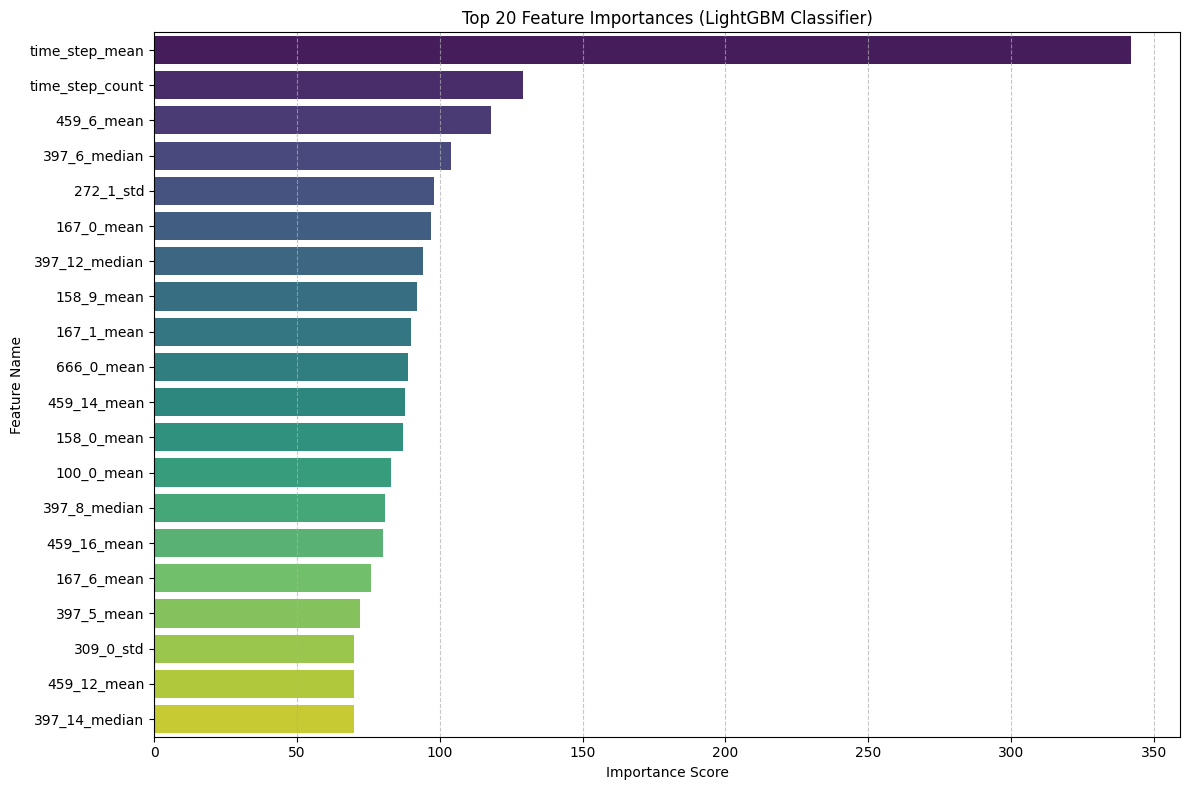

In [ ]:
# Visualize the top 20 LightGBM feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances_lgbm.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (LightGBM Classifier)')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Select features based on LightGBM importance scores
# Let's choose the top 50 features as an example threshold
num_top_features = 50
top_lgbm_features = feature_importances_lgbm.head(num_top_features)['feature'].tolist()

X_selected_lgbm = X_selected[top_lgbm_features]

print(f"Number of features after LightGBM-based selection (top {num_top_features}): {X_selected_lgbm.shape[1]}")
print("\nFirst 5 rows of the feature-selected DataFrame (X_selected_lgbm):")
display(X_selected_lgbm.head())

Number of features after LightGBM-based selection (top 50): 50

First 5 rows of the feature-selected DataFrame (X_selected_lgbm):


,time_step_mean,time_step_count,459_6_mean,397_6_median,272_1_std,167_0_mean,397_12_median,158_9_mean,167_1_mean,666_0_mean,...,397_7_median,459_15_mean,459_0_mean,167_1_min,397_4_median,158_7_mean,272_3_mean,158_8_mean,397_33_mean,time_step_min
0,258.130233,172,3421.977120,3995321.0,6.222639e+06,4110.500000,534501.0,2.377091e+06,1.299638e+06,197902.168605,...,5683654.0,17727.437094,2342.476876,1296420.0,128278.5,7.632524e+06,1.991734e+07,7.583241e+06,560261.418605,11.2
1,167.939394,33,3448.719014,4888789.0,1.129639e+07,6965.454545,508898.0,2.510993e+06,5.423560e+06,192030.212121,...,4850918.0,36055.035070,3764.383069,811605.0,210755.0,4.605784e+06,2.278320e+07,4.228648e+06,222924.727273,1.4
2,131.608451,71,1567.859282,2375946.0,3.363228e+06,3144.872340,278877.0,2.615055e+06,4.003922e+06,102097.492958,...,2588974.0,58898.881161,1245.453718,178155.0,333827.0,3.471012e+06,6.080694e+06,3.674812e+06,228721.971831,0.2
3,99.588235,17,1595.280069,2142757.0,2.641799e+06,6838.500000,216113.0,3.673181e+06,2.555733e+06,85981.352941,...,738350.0,47935.529807,1417.950729,2115617.0,70168.0,3.508956e+06,4.897866e+06,3.445333e+06,545739.764706,3.8
4,164.690909,44,1841.738837,4749063.0,7.678231e+06,29149.600000,430334.0,4.001820e+06,1.226105e+06,131730.204545,...,2025485.0,36570.488061,2566.417702,323910.0,376233.5,3.797466e+06,1.128923e+08,3.693746e+06,480050.818182,0.0


###### c. Permutation Importance: This is a model-agnostic technique that measures the importance of a feature by calculating how much the model's performance decreases when that feature's values are randomly shuffled. If shuffling a feature significantly drops performance, it's an important feature.

Calculating permutation importance... This may take a moment.

Top 20 Features by Permutation Importance (from the original 131 features):


,feature,mean_importance,std_importance
0,time_step_mean,0.046093,0.002440
1,397_6_median,0.002102,0.000565
2,459_6_mean,0.001975,0.000698
3,Spec_7_Cat1,0.001847,0.000485
4,time_step_count,0.001656,0.000703
5,158_5_mean,0.001465,0.000259
6,397_28_min,0.001401,0.000405
7,397_5_min,0.001338,0.000316
8,167_6_mean,0.001253,0.000633
9,459_14_mean,0.001231,0.000584



Permutation Importance for the LightGBM-selected top 50 features:


,feature,mean_importance,std_importance
0,time_step_mean,0.046093,0.002440
1,397_6_median,0.002102,0.000565
2,459_6_mean,0.001975,0.000698
3,time_step_count,0.001656,0.000703
4,158_5_mean,0.001465,0.000259
5,397_28_min,0.001401,0.000405
6,167_6_mean,0.001253,0.000633
7,459_14_mean,0.001231,0.000584
8,158_0_mean,0.001231,0.000443
9,100_0_mean,0.001146,0.000447


/tmp/ipykernel_1846/962431175.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_importance', y='feature', data=permutation_importances_lgbm_selected.head(20), palette='magma')


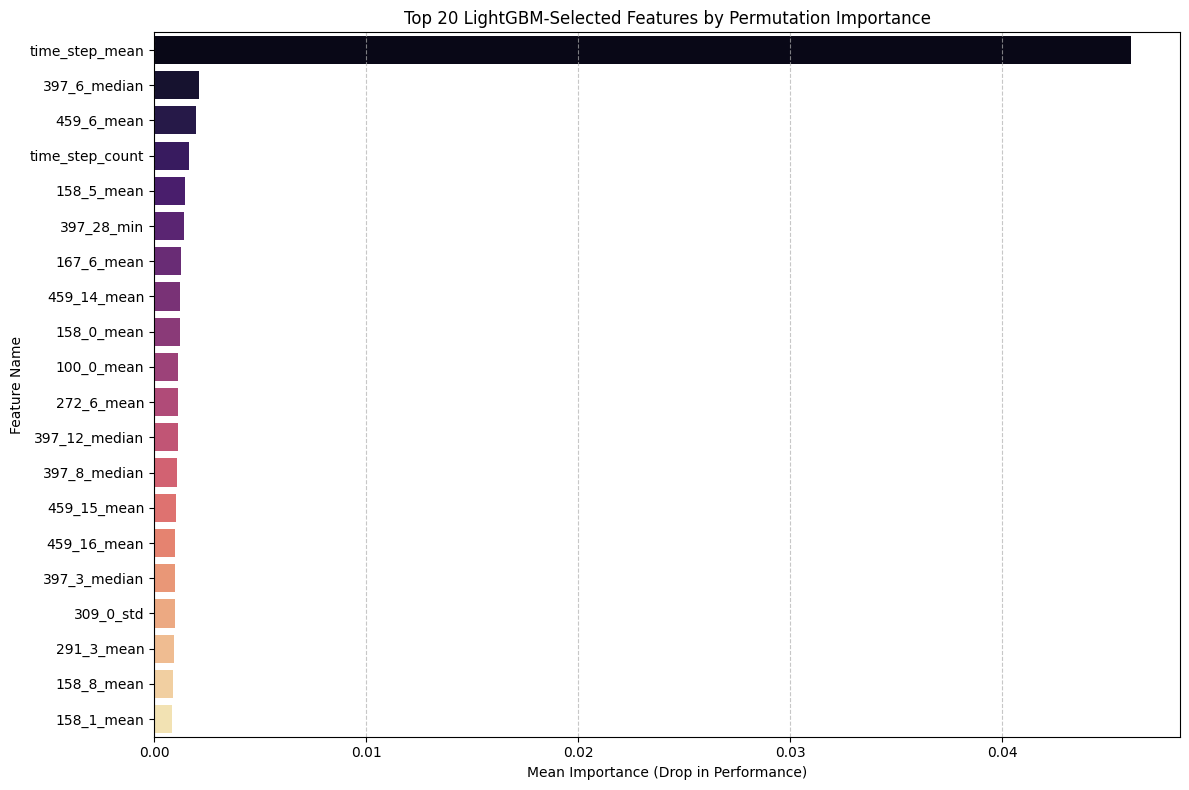

In [ ]:
from sklearn.inspection import permutation_importance

# Note: permutation_importance works best on a subset of data to reduce computation time
# We will use the X_test and y_test for this evaluation.
# The model `lgbm_clf` was trained on X_train (derived from X_selected, which has 131 features).
# Therefore, we must use X_test (which also has 131 features) for permutation importance.

print("Calculating permutation importance... This may take a moment.")

# Use X_test (which has 131 features) for permutation importance
result = permutation_importance(lgbm_clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

# Create a DataFrame for permutation importances for all 131 features
permutation_importances_full = pd.DataFrame({
    'feature': X_test.columns,
    'mean_importance': result.importances_mean,
    'std_importance': result.importances_std
})

# Sort by mean importance in descending order
permutation_importances_full = permutation_importances_full.sort_values(by='mean_importance', ascending=False).reset_index(drop=True)

print("\nTop 20 Features by Permutation Importance (from the original 131 features):")
display(permutation_importances_full.head(20))

# Now, let's filter these results to only show the permutation importance for the top 50 features
# that were selected by LightGBM's internal feature importance.
permutation_importances_lgbm_selected = permutation_importances_full[permutation_importances_full['feature'].isin(top_lgbm_features)]

# Re-sort these filtered importances
permutation_importances_lgbm_selected = permutation_importances_lgbm_selected.sort_values(by='mean_importance', ascending=False).reset_index(drop=True)

print("\nPermutation Importance for the LightGBM-selected top 50 features:")
display(permutation_importances_lgbm_selected)

# Visualize the top N features (e.g., top 20) from the LightGBM-selected set
plt.figure(figsize=(12, 8))
sns.barplot(x='mean_importance', y='feature', data=permutation_importances_lgbm_selected.head(20), palette='magma')
plt.title('Top 20 LightGBM-Selected Features by Permutation Importance')
plt.xlabel('Mean Importance (Drop in Performance)')
plt.ylabel('Feature Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The permutation importance results provide a robust validation of the features chosen by LightGBM. Features with higher mean importance scores (and lower standard deviations) are those that, when shuffled, cause the biggest drop in the model's performance, indicating their strong predictive power.

If there are significant discrepancies between LightGBM's internal importance and permutation importance, it might indicate issues like highly correlated features masking each other's importance in the model's internal calculations. However, seeing similar features rank high in both methods strengthens our confidence in their relevance.

##### Step 4: Dimensionality Reduction (Optional for Speed and Simplicity)
If, after feature selection, you still have a very high number of features, or if you want to reduce model complexity and potentially improve training speed, consider dimensionality reduction techniques:

Principal Component Analysis (PCA): PCA transforms your features into a new set of uncorrelated components (principal components), which capture the most variance in the data. You can then select a smaller number of these components to represent your data, effectively reducing the feature space.



### Validation Data - Load validation Data
Load the validation operational readouts, specifications, and labels from "/content/drive/MyDrive/MasterThesis-2026/Dataset/data/validation_operational_readouts.csv", "/content/drive/MyDrive/MasterThesis-2026/Dataset/data/validation_specifications.csv", and "/content/drive/MyDrive/MasterThesis-2026/Dataset/data/validation_labels.csv" into pandas DataFrames.


Load the validation operational readouts, specifications, and labels from `data_path_validation_operational_readouts`, `data_path_validation_specifications`, and `data_path_validation_labels` into pandas DataFrames.

In [ ]:
validation_operational_readout_data = pd.read_csv(data_path_validation_operational_readouts)
validation_specification_data = pd.read_csv(data_path_validation_specifications)
validation_labels_data = pd.read_csv(data_path_validation_labels)

print("First 5 rows of validation_operational_readout_data:")
display(validation_operational_readout_data.head())
print("Shape of validation_operational_readout_data:", validation_operational_readout_data.shape)

print("\nFirst 5 rows of validation_specification_data:")
display(validation_specification_data.head())
print("Shape of validation_specification_data:", validation_specification_data.shape)

print("\nFirst 5 rows of validation_labels_data:")
display(validation_labels_data.head())
print("Shape of validation_labels_data:", validation_labels_data.shape)

First 5 rows of validation_operational_readout_data:


,vehicle_id,time_step,171_0,666_0,427_0,837_0,167_0,167_1,167_2,167_3,...,397_26,397_27,397_28,397_29,397_30,397_31,397_32,397_33,397_34,397_35
0,10,3.0,46590.0,3696.0,2038959.0,1450.0,0.0,273826.0,339584.0,99834.0,...,100725.0,8026.0,855.0,15.0,495.0,91665.0,169125.0,51900.0,9362.0,0.0
1,10,7.4,127110.0,16716.0,6501456.0,4660.0,0.0,635642.0,609742.0,288036.0,...,295291.0,44312.0,7995.0,75.0,2265.0,414180.0,688891.0,258810.0,63167.0,1005.0
2,10,8.0,144015.0,19596.0,7327918.0,5230.0,0.0,654780.0,665756.0,300174.0,...,335479.0,52203.0,9421.0,75.0,2415.0,487080.0,812071.0,300735.0,77477.0,1500.0
3,10,12.0,187560.0,24264.0,9286082.0,7420.0,2647.0,831628.0,794332.0,360066.0,...,463265.0,61399.0,10727.0,75.0,2610.0,655620.0,1118116.0,403516.0,99587.0,1591.0
4,10,12.2,187575.0,24264.0,9286082.0,7420.0,NaN,NaN,NaN,NaN,...,463265.0,61400.0,10727.0,75.0,2611.0,655620.0,1118116.0,403517.0,99588.0,1592.0


Shape of validation_operational_readout_data: (196227, 107)

First 5 rows of validation_specification_data:


,vehicle_id,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,10,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1
1,16,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
2,18,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,23,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0
4,45,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1


Shape of validation_specification_data: (5046, 9)

First 5 rows of validation_labels_data:


,vehicle_id,class_label
0,10,0
1,16,0
2,18,0
3,23,0
4,45,0


Shape of validation_labels_data: (5046, 2)


### Validation data - Preprocessing

#### Feature Aggregate - Validation Operational Data

Apply the same aggregation logic (group by `vehicle_id` and calculate descriptive statistics for numerical columns using `mean`, `std`, `min`, `max`, `count`, and `median`) to `validation_operational_readout_data`. The numerical columns and aggregation functions will be consistent with those used for the training data. Store the result in a new DataFrame, e.g., `summary_validation_operational_readout`.


In [ ]:
import numpy as np
import pandas as pd

# Identify numerical columns (excluding 'vehicle_id')
# Reusing numerical_cols and aggregation_functions defined earlier for consistency
numerical_cols_validation = validation_operational_readout_data.select_dtypes(include=np.number).columns.drop('vehicle_id', errors='ignore').tolist()

# Ensure the aggregation_functions dictionary is available, redefine if not (though it should be in kernel)
# For robustness, let's assume it was defined and use it. If not, this would cause an error.
# aggregation_functions was defined in cell e1350621
# It maps each numerical column to ['mean', 'std', 'min', 'max', 'count', 'median']

# Group by 'vehicle_id' and aggregate
summary_validation_operational_readout = validation_operational_readout_data.groupby('vehicle_id').agg(aggregation_functions)

print("Shape of the summarized validation data:", summary_validation_operational_readout.shape)
print("\nFirst 5 rows of the summarized validation operational readout data by vehicle_id:")
display(summary_validation_operational_readout.head())

Shape of the summarized validation data: (5046, 636)

First 5 rows of the summarized validation operational readout data by vehicle_id:


time_step                                              171_0  \
                  mean         std  min    max count median          mean   
vehicle_id                                                                  
10          196.701961  109.656305  3.0  383.4   102  198.7  3.609082e+06   
16           70.540000   64.253023  5.4  198.6    20   33.8  1.513666e+06   
18          179.516981  107.441658  3.4  329.4    53  203.8  4.471608e+06   
23           35.914286   16.197551  0.4   60.8    35   38.2  1.060087e+06   
45          103.552113   62.995632  0.0  233.6    71  107.2  3.191426e+06   

                                              ...  397_34                   \
                     std      min        max  ...     min        max count   
vehicle_id                                    ...                            
10          2.283034e+06  46590.0  7652550.0  ...  9362.0   481488.0   102   
16          1.888635e+06  21585.0  5361765.0  ...   390.0   167879.0    20   
18          2.822730e+06  39465.0  8462820.0  ...  1216.0   321319.0    53   
23          4.343794e+05   1860.0  1652640.0  ...  1605.0    51934.0    35   
45          2.011073e+06  20295.0  7493130.0  ...    30.0  2293683.0    71   

                           397_35                                             
              median         mean          std    min      max count  median  
vehicle_id                                                                    
10          299865.0  5218.147059  1571.142287    0.0   6774.0   102  5766.0  
16            5750.0    93.300000   151.920027    0.0    452.0    20     7.5  
18          291011.0  2238.509434   854.667763  750.0   2870.0    53  2853.0  
23           38992.0    77.542857    62.090230   45.0    412.0    35    75.0  
45          895718.0  9161.887324  8258.858722    0.0  26707.0    71  6134.0  

[5 rows x 636 columns]

**Reasoning**:
The previous step successfully aggregated the data. Now, I need to flatten the multi-level column names of the `summary_validation_operational_readout` DataFrame for easier use, mirroring the process applied to the training data.



In [ ]:
summary_validation_operational_readout.columns = ['_'.join(col).strip() for col in summary_validation_operational_readout.columns.values]

print("First 5 rows of the summarized validation operational readout data with flattened column names:")
display(summary_validation_operational_readout.head())

print("Shape of the summarized validation data after flattening columns:", summary_validation_operational_readout.shape)

First 5 rows of the summarized validation operational readout data with flattened column names:


,time_step_mean,time_step_std,time_step_min,time_step_max,time_step_count,time_step_median,171_0_mean,171_0_std,171_0_min,171_0_max,...,397_34_min,397_34_max,397_34_count,397_34_median,397_35_mean,397_35_std,397_35_min,397_35_max,397_35_count,397_35_median
vehicle_id,,,,,,,,,,,,,,,,,,,,,
10,196.701961,109.656305,3.0,383.4,102,198.7,3.609082e+06,2.283034e+06,46590.0,7652550.0,...,9362.0,481488.0,102,299865.0,5218.147059,1571.142287,0.0,6774.0,102,5766.0
16,70.540000,64.253023,5.4,198.6,20,33.8,1.513666e+06,1.888635e+06,21585.0,5361765.0,...,390.0,167879.0,20,5750.0,93.300000,151.920027,0.0,452.0,20,7.5
18,179.516981,107.441658,3.4,329.4,53,203.8,4.471608e+06,2.822730e+06,39465.0,8462820.0,...,1216.0,321319.0,53,291011.0,2238.509434,854.667763,750.0,2870.0,53,2853.0
23,35.914286,16.197551,0.4,60.8,35,38.2,1.060087e+06,4.343794e+05,1860.0,1652640.0,...,1605.0,51934.0,35,38992.0,77.542857,62.090230,45.0,412.0,35,75.0
45,103.552113,62.995632,0.0,233.6,71,107.2,3.191426e+06,2.011073e+06,20295.0,7493130.0,...,30.0,2293683.0,71,895718.0,9161.887324,8258.858722,0.0,26707.0,71,6134.0


Shape of the summarized validation data after flattening columns: (5046, 636)


### Step 1a: Handling Missing Values in `summary_validation_operational_readout`

**Reasoning**:
To ensure data quality and consistency with the preprocessing of the training data, I will now identify and handle missing values in the `summary_validation_operational_readout` DataFrame. This involves calculating the percentage of missing values, dropping columns that exceed a 70% missing data threshold (if any), and then imputing any remaining missing values using the median for each column.



In [ ]:
import numpy as np

# Calculate the percentage of missing values for each column
missing_percentage_validation = summary_validation_operational_readout.isnull().sum() / len(summary_validation_operational_readout) * 100

# Display columns with missing values and their percentages, sorted descending
missing_percentage_validation = missing_percentage_validation[missing_percentage_validation > 0].sort_values(ascending=False)
print("Percentage of Missing Values per Feature in summary_validation_operational_readout (Top 20):")
display(missing_percentage_validation.head(20))

# Identify columns to drop if they have more than a certain threshold of missing values
# Using the same threshold as for training data (70%)
missing_threshold_validation = 70
columns_to_drop_validation = missing_percentage_validation[missing_percentage_validation > missing_threshold_validation].index.tolist()

if columns_to_drop_validation:
    print(f"\nColumns to drop (more than {missing_threshold_validation}% missing values): {len(columns_to_drop_validation)} columns")
    print(columns_to_drop_validation)
    summary_validation_operational_readout_cleaned = summary_validation_operational_readout.drop(columns=columns_to_drop_validation)
else:
    print(f"\nNo columns with more than {missing_threshold_validation}% missing values to drop.")
    summary_validation_operational_readout_cleaned = summary_validation_operational_readout.copy()

# Impute remaining missing values using the median
print("\nMissing values before imputation:")
print(summary_validation_operational_readout_cleaned.isnull().sum().sum())

for col in summary_validation_operational_readout_cleaned.columns:
    if summary_validation_operational_readout_cleaned[col].isnull().any():
        median_val = summary_validation_operational_readout_cleaned[col].median()
        summary_validation_operational_readout_cleaned[col].fillna(median_val, inplace=True)

print("\nMissing values after imputation:")
print(summary_validation_operational_readout_cleaned.isnull().sum().sum()) # Should be 0

print("\nFirst 5 rows of the cleaned summarized validation operational readout data:")
display(summary_validation_operational_readout_cleaned.head())

Percentage of Missing Values per Feature in summary_validation_operational_readout (Top 20):


,0
427_0_std,0.118906
291_2_std,0.118906
291_10_std,0.118906
291_7_std,0.118906
291_8_std,0.118906
291_9_std,0.118906
291_4_std,0.118906
291_3_std,0.118906
291_5_std,0.118906
291_6_std,0.118906



No columns with more than 70% missing values to drop.

Missing values before imputation:
502


/tmp/ipykernel_1846/687535669.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  summary_validation_operational_readout_cleaned[col].fillna(median_val, inplace=True)



Missing values after imputation:
0

First 5 rows of the cleaned summarized validation operational readout data:


,time_step_mean,time_step_std,time_step_min,time_step_max,time_step_count,time_step_median,171_0_mean,171_0_std,171_0_min,171_0_max,...,397_34_min,397_34_max,397_34_count,397_34_median,397_35_mean,397_35_std,397_35_min,397_35_max,397_35_count,397_35_median
vehicle_id,,,,,,,,,,,,,,,,,,,,,
10,196.701961,109.656305,3.0,383.4,102,198.7,3.609082e+06,2.283034e+06,46590.0,7652550.0,...,9362.0,481488.0,102,299865.0,5218.147059,1571.142287,0.0,6774.0,102,5766.0
16,70.540000,64.253023,5.4,198.6,20,33.8,1.513666e+06,1.888635e+06,21585.0,5361765.0,...,390.0,167879.0,20,5750.0,93.300000,151.920027,0.0,452.0,20,7.5
18,179.516981,107.441658,3.4,329.4,53,203.8,4.471608e+06,2.822730e+06,39465.0,8462820.0,...,1216.0,321319.0,53,291011.0,2238.509434,854.667763,750.0,2870.0,53,2853.0
23,35.914286,16.197551,0.4,60.8,35,38.2,1.060087e+06,4.343794e+05,1860.0,1652640.0,...,1605.0,51934.0,35,38992.0,77.542857,62.090230,45.0,412.0,35,75.0
45,103.552113,62.995632,0.0,233.6,71,107.2,3.191426e+06,2.011073e+06,20295.0,7493130.0,...,30.0,2293683.0,71,895718.0,9161.887324,8258.858722,0.0,26707.0,71,6134.0


**Reasoning**:
Following the same data cleaning steps as for the training data, the next step is to identify and address constant features in the `summary_validation_operational_readout_cleaned` DataFrame.



In [ ]:
### Step 1b: Handling Constant Values in `summary_validation_operational_readout`

**Reasoning**:
To ensure consistency with the training data preprocessing, I will identify and list any constant columns (columns with only one unique value) in the `summary_validation_operational_readout_cleaned` DataFrame.



In [ ]:
constant_columns_validation = [col for col in summary_validation_operational_readout_cleaned.columns if summary_validation_operational_readout_cleaned[col].nunique() == 1]

if constant_columns_validation:
    print("\nIdentified Constant Features in summary_validation_operational_readout_cleaned:")
    for col in constant_columns_validation:
        print(f"- {col}: Unique value = {summary_validation_operational_readout_cleaned[col].iloc[0]}")
else:
    print("\nNo constant features identified in summary_validation_operational_readout_cleaned.")


No constant features identified in summary_validation_operational_readout_cleaned.


### Step 1c: Handling Highly co-related features in `summary_validation_operational_readout_cleaned`

**Reasoning**:
To maintain consistency with the preprocessing of the training data, I will now identify and remove highly correlated features from the `summary_validation_operational_readout_cleaned` DataFrame. I will use the `columns_to_drop_from_corr` identified during the training data preprocessing to ensure that the validation set has the same feature space as the training set.



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure columns_to_drop_from_corr from the training data step is available
# If this variable is not available in the kernel, it needs to be recreated or imported.
# For consistency, we will drop the same columns as identified in the training data.

# Create a copy to perform cleaning
summary_validation_operational_readout_cleaned_final = summary_validation_operational_readout_cleaned.copy()

# Check if columns_to_drop_from_corr exists and is not empty
if 'columns_to_drop_from_corr' in locals() and columns_to_drop_from_corr:
    # Filter only the columns that actually exist in the validation set
    columns_to_drop_from_corr_validation_existing = [col for col in columns_to_drop_from_corr if col in summary_validation_operational_readout_cleaned_final.columns]

    if columns_to_drop_from_corr_validation_existing:
        print(f"\nDropping {len(columns_to_drop_from_corr_validation_existing)} highly correlated features from validation data (as identified in training data):")
        print(columns_to_drop_from_corr_validation_existing)
        summary_validation_operational_readout_cleaned_final = summary_validation_operational_readout_cleaned_final.drop(columns=columns_to_drop_from_corr_validation_existing)
        print(f"New shape of the validation DataFrame: {summary_validation_operational_readout_cleaned_final.shape}")
    else:
        print("\nNo highly correlated features from training data found in validation data to drop.")
else:
    print("\n'columns_to_drop_from_corr' was not defined or was empty from training data; skipping dropping correlated features.")

print("\nFirst 5 rows of the validation DataFrame after handling highly correlated features:")
display(summary_validation_operational_readout_cleaned_final.head())


Dropping 481 highly correlated features from validation data (as identified in training data):
['158_1_min', '459_15_std', '397_16_mean', '459_13_count', '291_2_mean', '272_3_std', '397_1_max', '459_9_mean', '397_24_max', '459_9_std', '459_10_median', '158_1_max', '837_0_max', '397_28_mean', '291_4_std', '397_31_median', '397_22_mean', '397_3_count', '459_12_min', '397_30_std', '397_28_max', '397_35_std', '397_16_std', '167_8_std', '397_33_max', '291_2_max', '459_0_std', '397_29_std', '158_6_median', '158_3_max', '171_0_median', '167_5_max', '291_9_max', '397_18_max', '291_4_min', '397_35_max', '158_0_count', '291_3_median', '459_7_min', '397_17_count', '459_16_count', '459_11_count', '167_0_max', '459_17_median', '397_26_mean', '291_3_std', '397_3_max', '666_0_max', '272_7_max', '397_7_mean', '167_6_median', '459_4_min', '171_0_std', '158_4_max', '397_13_std', '309_0_median', '167_1_max', '459_5_mean', '158_7_median', '291_5_count', '397_7_count', '272_4_median', '167_3_max', '272_4_

,time_step_mean,time_step_min,time_step_count,171_0_mean,171_0_min,666_0_mean,666_0_min,837_0_mean,837_0_std,167_0_mean,...,397_31_mean,397_31_min,397_32_mean,397_32_min,397_33_mean,397_33_min,397_34_mean,397_34_min,397_35_mean,397_35_min
vehicle_id,,,,,,,,,,,,,,,,,,,,,
10,196.701961,3.0,102,3.609082e+06,46590.0,207221.166667,3696.0,58635.696078,31629.663911,27631.933333,...,5.307042e+06,91665.0,7.803498e+06,169125.0,1.494318e+06,51900.0,288459.264706,9362.0,5218.147059,0.0
16,70.540000,5.4,20,1.513666e+06,21585.0,82286.500000,144.0,16937.250000,22040.675130,245.500000,...,6.443814e+05,60.0,1.456674e+06,105.0,2.341817e+05,45.0,42068.150000,390.0,93.300000,0.0
18,179.516981,3.4,53,4.471608e+06,39465.0,209399.169811,2088.0,57309.377358,33041.958968,0.000000,...,1.076469e+06,20970.0,3.276977e+06,35040.0,9.192671e+05,5175.0,221048.660377,1216.0,2238.509434,750.0
23,35.914286,0.4,35,1.060087e+06,1860.0,34473.142857,12.0,6298.171429,3864.293075,1353.000000,...,5.187011e+05,75.0,1.305137e+06,810.0,2.461519e+05,120.0,38227.342857,1605.0,77.542857,45.0
45,103.552113,0.0,71,3.191426e+06,20295.0,308390.056338,36.0,93869.014085,60095.921444,54731.154930,...,9.765019e+06,0.0,1.545995e+07,15.0,2.870201e+06,75.0,965608.957746,30.0,9161.887324,0.0


**Reasoning**:
To create a comprehensive validation dataset for model training and evaluation, I will merge the cleaned and feature-selected operational readout data with the validation labels and specifications, using 'vehicle_id' as the key.



In [ ]:
merged_validation_data = pd.merge(summary_validation_operational_readout_cleaned_final, validation_labels_data, on='vehicle_id', how='left')
merged_validation_data = pd.merge(merged_validation_data, validation_specification_data, on='vehicle_id', how='left')

print("Shape of the final merged validation data:", merged_validation_data.shape)
print("\nFirst 5 rows of the final merged validation data:")
display(merged_validation_data.head())

print("\nInformation about the final merged validation data:")
merged_validation_data.info()

# Quick check for missing values in the newly merged columns
print("\nMissing values in the merged validation data (top 20):")
display(merged_validation_data.isnull().sum()[merged_validation_data.isnull().sum() > 0].sort_values(ascending=False).head(20))

Shape of the final merged validation data: (5046, 165)

First 5 rows of the final merged validation data:


,vehicle_id,time_step_mean,time_step_min,time_step_count,171_0_mean,171_0_min,666_0_mean,666_0_min,837_0_mean,837_0_std,...,397_35_min,class_label,Spec_0,Spec_1,Spec_2,Spec_3,Spec_4,Spec_5,Spec_6,Spec_7
0,10,196.701961,3.0,102,3.609082e+06,46590.0,207221.166667,3696.0,58635.696078,31629.663911,...,0.0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1
1,16,70.540000,5.4,20,1.513666e+06,21585.0,82286.500000,144.0,16937.250000,22040.675130,...,0.0,0,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
2,18,179.516981,3.4,53,4.471608e+06,39465.0,209399.169811,2088.0,57309.377358,33041.958968,...,750.0,0,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat1
3,23,35.914286,0.4,35,1.060087e+06,1860.0,34473.142857,12.0,6298.171429,3864.293075,...,45.0,0,Cat0,Cat1,Cat1,Cat1,Cat0,Cat0,Cat0,Cat0
4,45,103.552113,0.0,71,3.191426e+06,20295.0,308390.056338,36.0,93869.014085,60095.921444,...,0.0,0,Cat0,Cat0,Cat0,Cat0,Cat0,Cat1,Cat0,Cat1



Information about the final merged validation data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5046 entries, 0 to 5045
Columns: 165 entries, vehicle_id to Spec_7
dtypes: float64(154), int64(3), object(8)
memory usage: 6.4+ MB

Missing values in the merged validation data (top 20):


,0


## Prepare validation features for model input

### Subtask:
Prepare the `merged_validation_data` by separating features and target, one-hot encoding categorical features, and then selecting the features based on the top features identified from the training data (`top_lgbm_features`).


**Reasoning**:
The subtask requires several data preparation steps: separating features and target, one-hot encoding categorical features, and then selecting features based on `top_lgbm_features` from the training data. I will combine these steps into a single code block for efficiency and consistency with previous data processing.



In [ ]:
import pandas as pd

# 1. Separate features (X_validation) and target (y_validation)
X_validation = merged_validation_data.drop(columns=['vehicle_id', 'class_label'])
y_validation = merged_validation_data['class_label']

# 2. Identify all categorical columns within X_validation
categorical_cols_validation = X_validation.select_dtypes(include='object').columns

# 3. Apply one-hot encoding to these categorical columns in X_validation
X_validation_encoded = pd.get_dummies(X_validation, columns=categorical_cols_validation, drop_first=True)

print("Shape of X_validation after one-hot encoding:", X_validation_encoded.shape)

# 4. Select only the columns that are present in features_to_keep (from training's statistical selection)
# This ensures the validation set has the same features as the training set used for model training.

# Get the columns from the training set's feature selection (X_selected)
training_features_columns = X_selected.columns

# Align validation features with training features
X_validation_final = X_validation_encoded.reindex(columns=training_features_columns, fill_value=0)

# 5. Print the shape and display the first 5 rows of X_validation_final and y_validation.
print(f"\nShape of X_validation_final (aligned with training features): {X_validation_final.shape}")
print("First 5 rows of X_validation_final:")
display(X_validation_final.head())

print(f"\nShape of y_validation: {y_validation.shape}")
print("First 5 rows of y_validation:")
display(y_validation.head())

Shape of X_validation after one-hot encoding: (5046, 235)

Shape of X_validation_final (aligned with training features): (5046, 131)
First 5 rows of X_validation_final:


,Spec_2_Cat17,291_6_min,Spec_3_Cat3,167_3_mean,Spec_7_Cat2,397_3_min,Spec_2_Cat1,Spec_6_Cat7,397_12_median,397_33_min,...,272_1_std,459_6_mean,167_2_mean,167_7_mean,Spec_5_Cat1,459_0_mean,Spec_7_Cat8,397_27_min,167_8_mean,397_25_mean
0,False,177.0,False,1.690719e+07,False,12510.0,False,False,2026441.0,51900.0,...,844914.036643,8023.396608,1.858128e+07,7.032316e+05,True,4103.413111,False,8026.0,11423.600000,3.688824e+06
1,False,120.0,False,1.555470e+05,False,5220.0,True,False,222804.5,45.0,...,385984.047497,1218.499351,3.929905e+05,0.000000e+00,False,1587.451441,False,120.0,0.000000,9.699015e+05
2,False,248.0,False,6.319700e+04,False,9886.0,True,False,1664562.0,5175.0,...,794546.902388,3075.442336,2.015860e+05,5.922000e+03,False,7060.646094,False,4515.0,0.000000,2.262118e+06
3,False,424.0,False,6.591856e+05,False,735.0,True,False,691836.0,120.0,...,147911.562252,925.960698,1.430806e+06,5.850960e+04,False,1706.789998,False,15.0,5074.400000,8.063170e+05
4,False,121.0,False,5.238568e+06,False,11176.0,False,False,790201.0,75.0,...,717448.083479,4727.770899,1.321993e+07,3.640603e+06,True,4213.861543,False,75.0,219491.901408,2.877856e+06



Shape of y_validation: (5046,)
First 5 rows of y_validation:


,class_label
0,0
1,0
2,0
3,0
4,0
